## 1. Imports

In [244]:
# import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

from pycaret.regression import setup, compare_models

import joblib
import os

warnings.filterwarnings('ignore')

## 2. Load Data

In [245]:
# Notebook 2 (Training): Load
df_final = pd.read_parquet('../data/tehranhouses_preprocessed.parquet')
df_final.head()

,Area,Room,Parking,Warehouse,Elevator,Price(USD),Address_Abbasabad,Address_Absard,Address_Abuzar,Address_Afsarieh,Address_Ahang,Address_Air force,Address_Ajudaniye,Address_Alborz Complex,Address_Aliabad South,Address_Amir Bahador,Address_Amirabad,Address_Amirieh,Address_Andisheh,Address_Aqdasieh,Address_Araj,Address_Argentina,Address_Atabak,Address_Azadshahr,Address_Azarbaijan,Address_Azari,Address_Baghestan,Address_Bahar,Address_Baqershahr,Address_Beryanak,Address_Boloorsazi,Address_Central Janatabad,Address_Chahardangeh,Address_Chardangeh,Address_Chardivari,Address_Chidz,Address_Damavand,Address_Darabad,Address_Darakeh,Address_Darband,Address_Daryan No,Address_Dehkade Olampic,Address_Dezashib,Address_Dolatabad,Address_Dorous,Address_East Ferdows Boulevard,Address_East Pars,Address_Ekbatan,Address_Ekhtiarieh,Address_Elahieh,Address_Elm-o-Sanat,Address_Enghelab,Address_Eram,Address_Eskandari,Address_Fallah,Address_Farmanieh,Address_Fatemi,Address_Feiz Garden,Address_Firoozkooh,Address_Firoozkooh Kuhsar,Address_Gandhi,Address_Garden of Saba,Address_Gheitarieh,Address_Ghiyamdasht,Address_Ghoba,Address_Gholhak,Address_Gisha,Address_Golestan,Address_Haft Tir,Address_Hakimiyeh,Address_Hashemi,Address_Hassan Abad,Address_Hekmat,Address_Heravi,Address_Heshmatieh,Address_Hor Square,Address_Islamshahr,Address_Islamshahr Elahieh,Address_Javadiyeh,Address_Jeyhoon,Address_Jordan,Address_Kahrizak,Address_Kamranieh,Address_Karimkhan,Address_Karoon,Address_Kazemabad,Address_Keshavarz Boulevard,Address_Khademabad Garden,Address_Khavaran,Address_Komeil,Address_Koohsar,Address_Kook,Address_Lavasan,Address_Lavizan,Address_Mahallati,Address_Mahmoudieh,Address_Majidieh,Address_Malard,Address_Marzdaran,Address_Mehrabad,Address_Mehrabad River River,Address_Mehran,Address_Mirdamad,Address_Mirza Shirazi,Address_Moniriyeh,Address_Narmak,Address_Nasim Shahr,Address_Nawab,Address_Naziabad,Address_Nezamabad,Address_Niavaran,Address_North Program Organization,Address_Northern Chitgar,Address_Northern Janatabad,Address_Northern Suhrawardi,Address_Northren Jamalzadeh,Address_Ostad Moein,Address_Ozgol,Address_Pakdasht,Address_Pakdasht KhatunAbad,Address_Parand,Address_Parastar,Address_Pardis,Address_Pasdaran,Address_Persian Gulf Martyrs Lake,Address_Pirouzi,Address_Pishva,Address_Punak,Address_Qalandari,Address_Qarchak,Address_Qasr-od-Dasht,Address_Qazvin Imamzadeh Hassan,Address_Railway,Address_Ray,Address_Ray - Montazeri,Address_Ray - Pilgosh,Address_Razi,Address_Republic,Address_Robat Karim,Address_Rudhen,Address_Saadat Abad,Address_SabaShahr,Address_Sabalan,Address_Sadeghieh,Address_Safadasht,Address_Salehabad,Address_Salsabil,Address_Sattarkhan,Address_Seyed Khandan,Address_Shadabad,Address_Shahedshahr,Address_Shahr-e-Ziba,Address_ShahrAra,Address_Shahrake Apadana,Address_Shahrake Azadi,Address_Shahrake Gharb,Address_Shahrake Madaen,Address_Shahrake Qods,Address_Shahrake Quds,Address_Shahrake Shahid Bagheri,Address_Shahrakeh Naft,Address_Shahran,Address_Shahryar,Address_Shams Abad,Address_Shoosh,Address_Si Metri Ji,Address_Sohanak,Address_Southern Chitgar,Address_Southern Janatabad,Address_Southern Program Organization,Address_Southern Suhrawardi,Address_Tajrish,Address_Tarasht,Address_Taslihat,Address_Tehran Now,Address_Tehransar,Address_Telecommunication,Address_Tenant,Address_Thirteen November,Address_Vahidieh,Address_Vahidiyeh,Address_Valiasr,Address_Vanak,Address_Varamin - Beheshti,Address_Velenjak,Address_Villa,Address_Water Organization,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,-0.625034,-1.444908,1,1,1,61666.67,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

In [246]:
# Feature / Target Split
X = df_final.drop('Price(USD)', axis=1)
y = df_final['Price(USD)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2752, 196)  |  Test: (688, 196)


In [ ]:
# Initialize PyCaret Setup
exp_reg = setup(
    data=df_final,
    target='Price(USD)',
    session_id=42,
    train_size=0.8,
    normalize=True,
    normalize_method='zscore',
    n_jobs=1,
    system_log=False
)

best_model = compare_models(
    include=[
        'lightgbm',  # LightGBM
        'catboost',  # CatBoost
        'xgboost',   # XGBoost
        'rf',        # Random Forest
        'gbr',       # Gradient Boosting
        'knn'        # K-Nearest Neighbors
    ],
    fold=5,
    sort='R2'
)

,Description,Value
0,Session id,42
1,Target,Price(USD)
2,Target type,Regression
3,Original data shape,"(3440, 197)"
4,Transformed data shape,"(3440, 197)"
5,Transformed train set shape,"(2752, 197)"
6,Transformed test set shape,"(688, 197)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,46787.4972,13429513632.3024,113761.5327,0.8211,0.4662,0.3968,0.6960
gbr,Gradient Boosting Regressor,56561.3062,16459474125.8889,125795.5237,0.7815,0.5510,0.5884,0.3280
xgboost,Extreme Gradient Boosting,49235.2031,17039718400.0000,128374.1391,0.7712,0.4699,0.3809,0.1560
rf,Random Forest Regressor,50101.9340,17251386056.6221,128900.3192,0.7672,0.4450,0.3949,0.8900
lightgbm,Light Gradient Boosting Machine,56375.4477,17674347461.3811,131807.5266,0.7583,0.5598,0.5030,0.1040
knn,K Neighbors Regressor,55164.0523,24554843545.6000,155284.6094,0.6653,0.4748,0.4307,0.0620


In [248]:
# # Define the parameter grid for tuning
# param_grid = {
#     'n_estimators': [600],
#     'learning_rate': [0.05],
#     'min_samples_leaf': [1],
#     # 'subsample': [0.4, 0.5, 0.6, 0.7],
#     'max_depth': [9, 11],
# }

# # Set up the GridSearchCV
# grid_search = GridSearchCV(
#     estimator=GradientBoostingRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=5,              # 5-fold cross-validation
#     scoring='r2',
#     n_jobs=-1          # Use all available CPU cores
# )

# # Run the grid search
# grid_search.fit(X_train, y_train)

In [ ]:
# Define the parameter grid for tuning
param_grid = {
    'iterations': [800],
    'learning_rate': [0.075],
    'depth': [13],
}

# Set up the GridSearchCV with CatBoostRegressor
grid_search = GridSearchCV(
    estimator=CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False),
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1          # Use all available CPU cores
)

# Run the grid search
grid_search.fit(
    X_train, 
    y_train, 
    allow_writing_files=False
)

GridSearchCV(cv=5,
             estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
             n_jobs=-1,
             param_grid={'depth': [13], 'iterations': [800],
                         'learning_rate': [0.075]},
             scoring='r2')

In [250]:
# Print out the best parameters and cross-validation score
print("Best hyperparameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy: {:.2f}".format(grid_search.best_score_ ))

model = grid_search.best_estimator_

# Predict & Evaluate
print(f"\nModel Performance On Test set:")

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"        R^2 Score: {r2:.4f}")
print(f"        MSE: {mse:.4f}")
print("         RMSE: %f" % (rmse))

Best hyperparameters found:
{'depth': 13, 'iterations': 800, 'learning_rate': 0.075}

Best cross-validation accuracy: 0.81

Model Performance On Test set:
        R^2 Score: 0.5832
        MSE: 28416363670.9093
         RMSE: 168571.538733


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

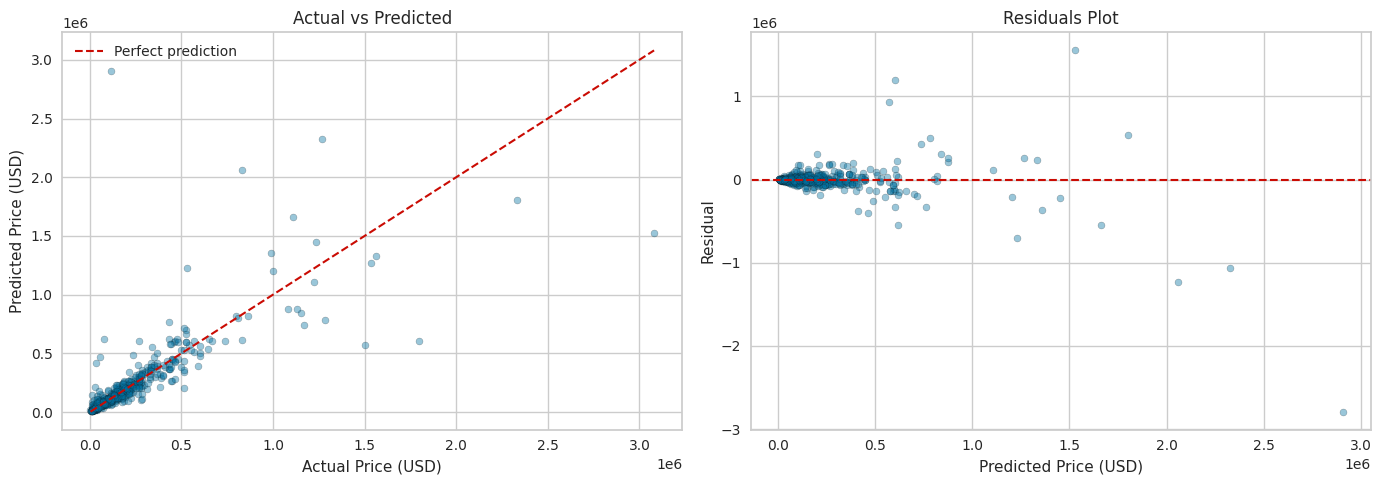

In [251]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_pred_best = model.predict(X_test)

# Scatter: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
lim = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)'); ax.set_ylabel('Predicted Price (USD)')
ax.set_title(f'Actual vs Predicted'); ax.legend()

# Residuals
ax = axes[1]
residuals = y_test.values - y_pred_best
ax.scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
ax.axhline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Price (USD)'); ax.set_ylabel('Residual')
ax.set_title('Residuals Plot')

plt.tight_layout(); plt.show()

### Feature Importances

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

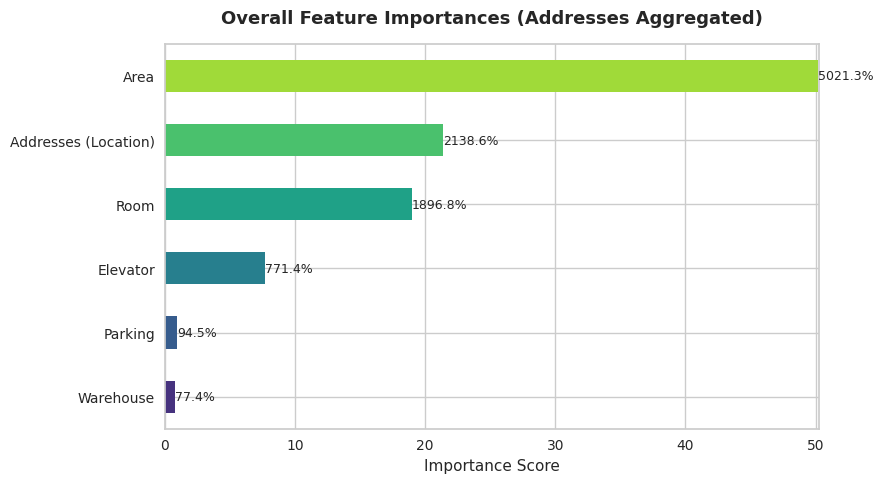

In [252]:
# Feature Importances
if hasattr(model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
    
    # Extract and sum up all one-hot encoded 'Address_' column scores
    address_mask = imp.index.str.startswith('Address_')
    total_address_importance = imp[address_mask].sum()
    
    # Build a new series grouping all other numerical features + the unified Address score
    grouped_imp = imp[~address_mask].copy()
    grouped_imp['Addresses (Location)'] = total_address_importance
    
    # Sort them for the plot
    grouped_imp = grouped_imp.sort_values(ascending=True)

    # Plot the unified feature importances
    plt.figure(figsize=(9, 5))
    grouped_imp.plot.barh(color=sns.color_palette('viridis', len(grouped_imp)))
    
    # Add data labels inside/next to the bars
    for i, val in enumerate(grouped_imp.values):
        plt.text(val + 0.005, i, f"{val*100:.1f}%", va='center', fontsize=9, fontweight='medium')
        
    plt.title('Overall Feature Importances (Addresses Aggregated)', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Importance Score')
    plt.xlim(0, max(grouped_imp.values) + 0.08)  # Leave room for text labels
    plt.tight_layout()
    plt.show()
else:
    print("The best model does not expose feature_importances_.")

## Save Trained Model

In [ ]:
# # Save Trained Model
# os.makedirs('saved_models', exist_ok=True)

# model_filename = 'saved_models/tehran_housing_best_model.pkl'
# features_filename = 'saved_models/model_features.pkl'

# # Save the best model and the specific column layout
# joblib.dump(model, model_filename, compress=3)
# # joblib.dump(model, model_filename)
# joblib.dump(X_train.columns.tolist(), features_filename)

['saved_models/model_features.pkl']